In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
#Step 2 — Load the Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("CC GENERAL.csv")  # Make sure the CSV is in the same folder as your notebook

# First Look
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (8950, 18)

First 5 rows:


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
#Step 3 — Understand the Data Structure

# Check column names, data types and missing values
print("=== Column Info ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Statistics ===")
df.describe()

=== Column Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null  

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [4]:
#Step 4 — Handle Missing Values + Drop CUST_ID

# Fill missing values with median (updated syntax - no warning)
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())

# Drop CUST_ID
df.drop(columns=['CUST_ID'], inplace=True)

# Confirm
print("Missing values after cleaning:", df.isnull().sum().sum())
print("New Shape:", df.shape)

Missing values after cleaning: 0
New Shape: (8950, 17)


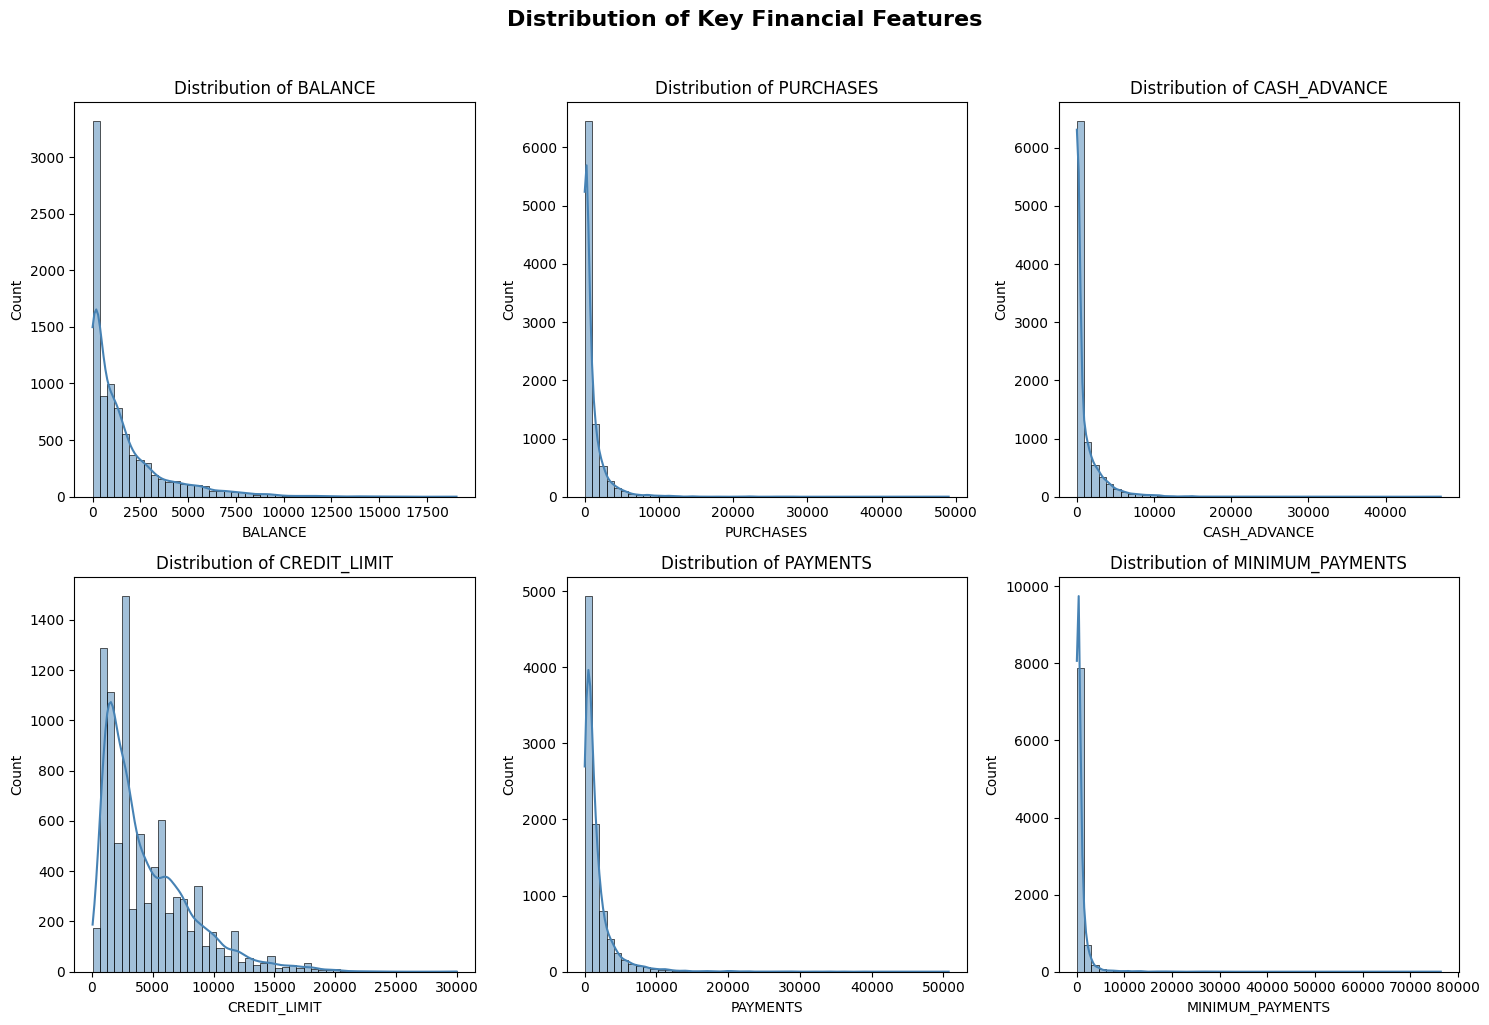

Distribution plots saved!


In [6]:
#Exploratory Data Analysis
#Step 5 — Distribution Plots (Key Columns)

# Distribution plots for key financial columns
cols = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS']

plt.figure(figsize=(15, 10))
for i, col in enumerate(cols):
    plt.subplot(2, 3, i+1)
    sns.histplot(df[col], bins=50, kde=True, color='steelblue')
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.xlabel(col)
    plt.ylabel('Count')

plt.suptitle('Distribution of Key Financial Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('distribution_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Distribution plots saved!")

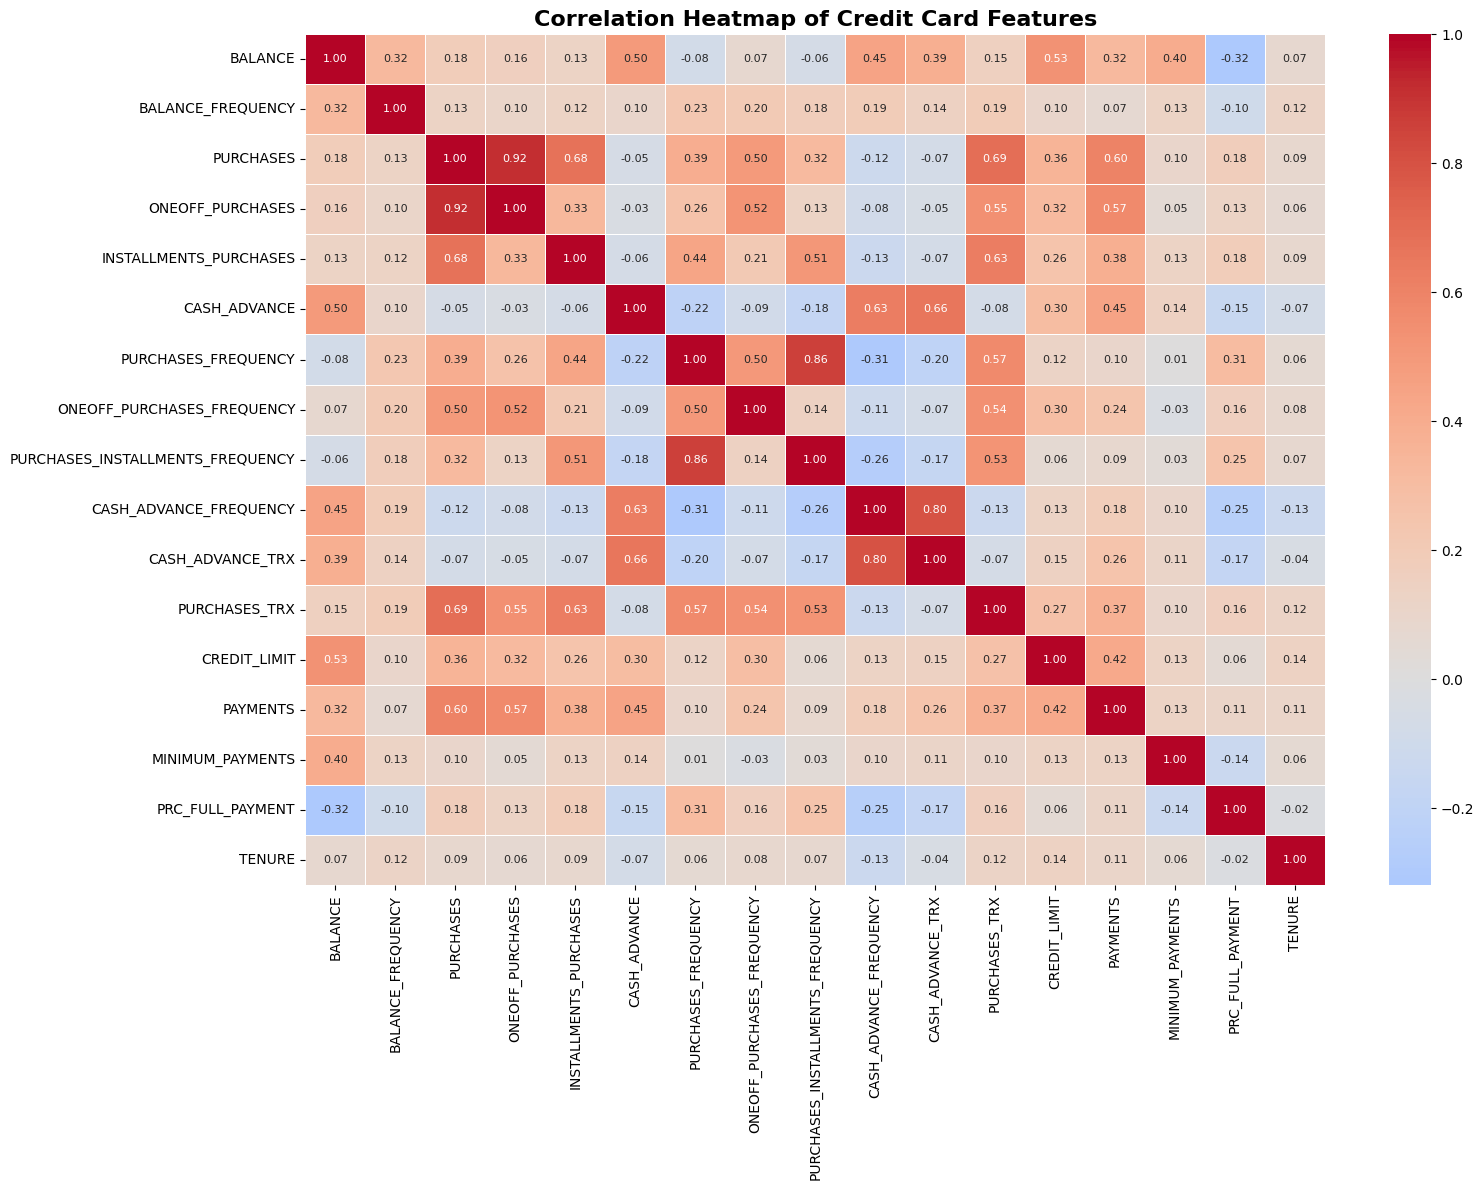

Correlation heatmap saved!


In [7]:
#Step 6 — Correlation Heatmap

# Correlation Heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(), 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            annot_kws={"size": 8})

plt.title('Correlation Heatmap of Credit Card Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Correlation heatmap saved!")

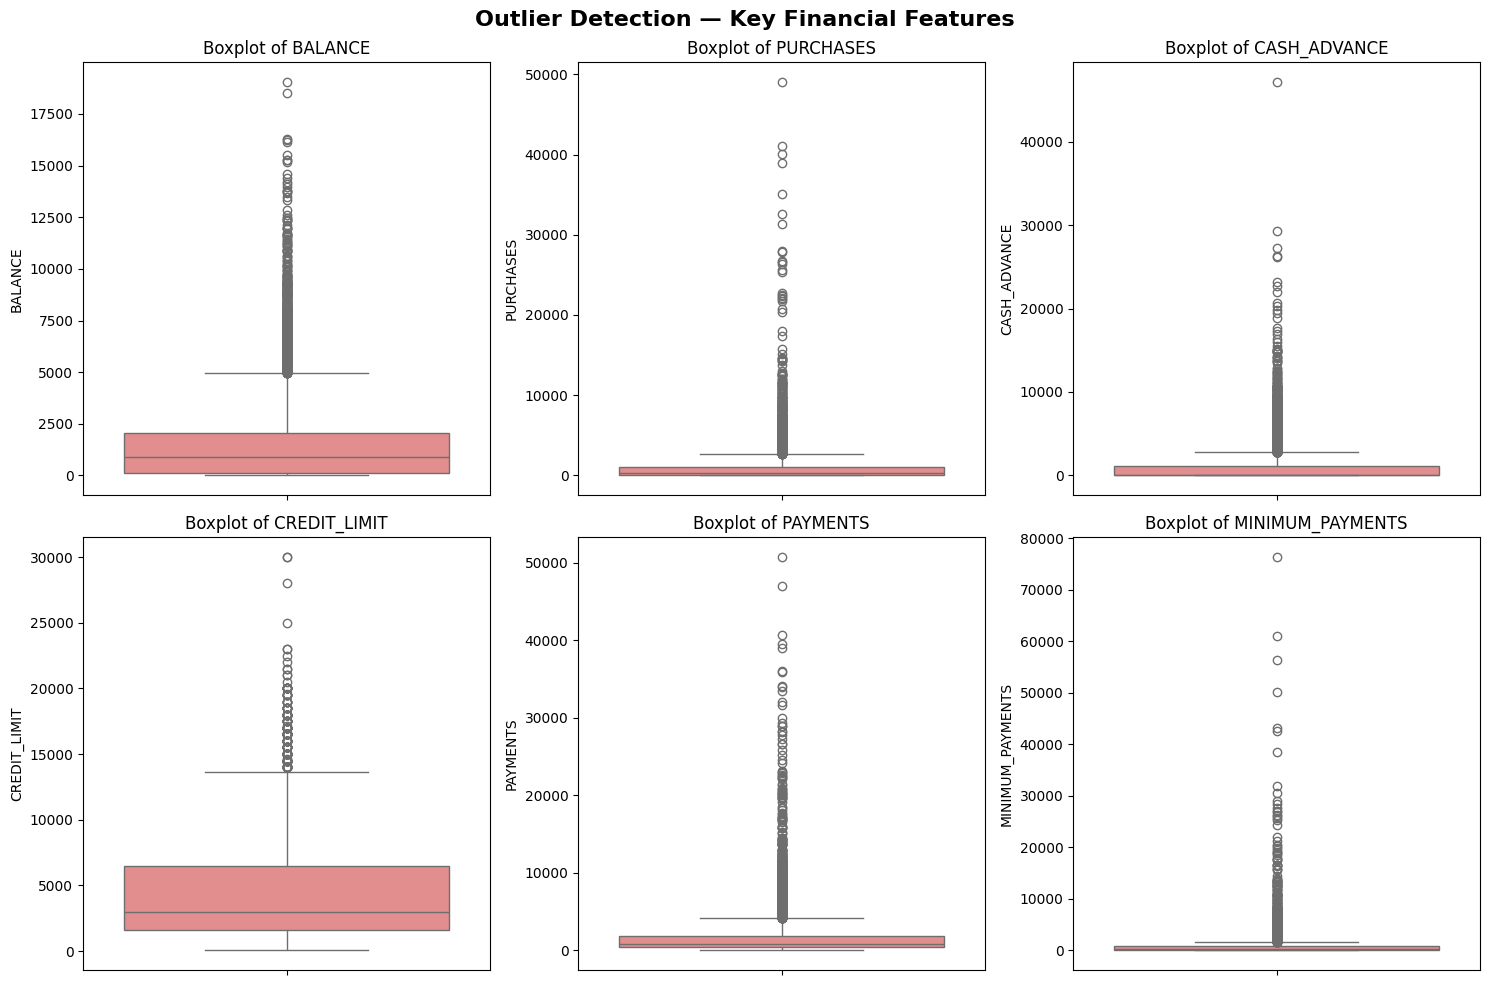

Boxplots saved!


In [8]:
#Step 7 — Boxplots for Outlier Detection

# Boxplots to visualize outliers
cols = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS']

plt.figure(figsize=(15, 10))
for i, col in enumerate(cols):
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=df[col], color='lightcoral')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.ylabel(col)

plt.suptitle('Outlier Detection — Key Financial Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Boxplots saved!")

In [9]:
#Step 8 — Feature Scaling

from sklearn.preprocessing import StandardScaler

# Scale all features
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# Convert back to dataframe
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

print("Scaling done!")
print("\nSample scaled values:")
df_scaled.head()

Scaling done!

Sample scaled values:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960378,-0.528979,-0.302400,-0.525551,0.36068
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688678,0.818642,0.097500,0.234227,0.36068
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826100,-0.383805,-0.093293,-0.525551,0.36068
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826100,-0.598688,-0.228307,-0.525551,0.36068
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905410,-0.364368,-0.257266,-0.525551,0.36068


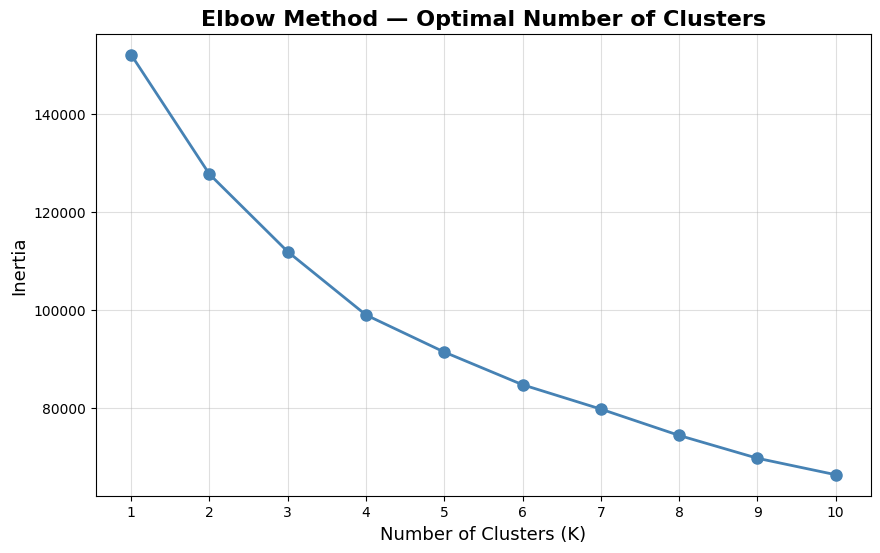

Elbow curve saved!


In [10]:
#Day 2 — Core Analysis + Clustering
#Step 9 — Elbow Method (Find Optimal K)

from sklearn.cluster import KMeans

# Elbow Method
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', color='steelblue', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=13)
plt.ylabel('Inertia', fontsize=13)
plt.title('Elbow Method — Optimal Number of Clusters', fontsize=16, fontweight='bold')
plt.xticks(K_range)
plt.grid(True, alpha=0.4)
plt.savefig('elbow_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Elbow curve saved!")

K=2 → Silhouette Score: 0.2100
K=3 → Silhouette Score: 0.2510
K=4 → Silhouette Score: 0.1977
K=5 → Silhouette Score: 0.1931
K=6 → Silhouette Score: 0.2029
K=7 → Silhouette Score: 0.2077
K=8 → Silhouette Score: 0.2217
K=9 → Silhouette Score: 0.2260
K=10 → Silhouette Score: 0.2204


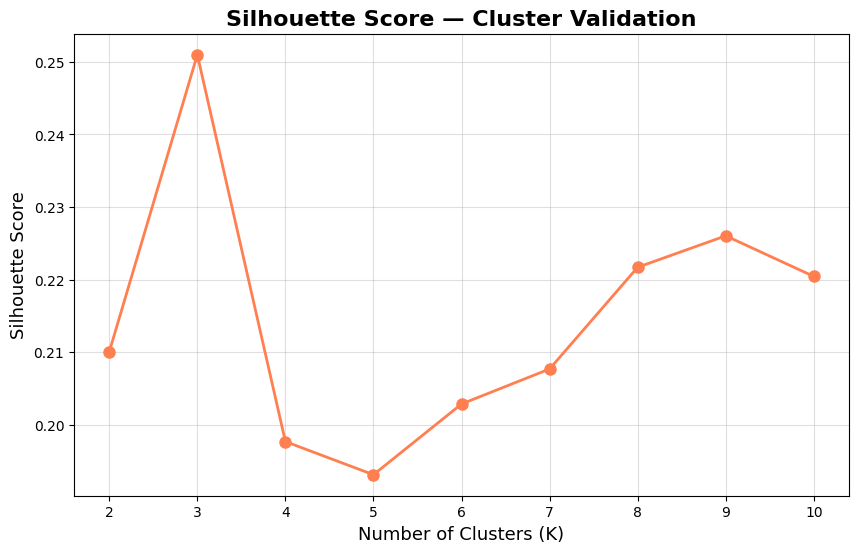

Silhouette plot saved!


In [12]:
#Step 10 — Silhouette Score (Validate K)

from sklearn.metrics import silhouette_score

# Silhouette scores for K = 2 to 10
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    sil_scores.append(score)
    print(f"K={k} → Silhouette Score: {score:.4f}")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(K_range, sil_scores, marker='o', color='coral', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=13)
plt.ylabel('Silhouette Score', fontsize=13)
plt.title('Silhouette Score — Cluster Validation', fontsize=16, fontweight='bold')
plt.xticks(K_range)
plt.grid(True, alpha=0.4)
plt.savefig('silhouette_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print("Silhouette plot saved!")

In [13]:
#Step 11 — Fit K-Means with K=3

# Final K-Means model with K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(df_scaled)

# Check cluster sizes
print("Clustering Done!")
print("\nCustomer count per cluster:")
print(df['Cluster'].value_counts().sort_index())

Clustering Done!

Customer count per cluster:
Cluster
0    1275
1    6114
2    1561
Name: count, dtype: int64


In [14]:
#Step 12 — Cluster Profile Analysis

# Average values per cluster (original unscaled data for readability)
cluster_profile = df.groupby('Cluster').mean().round(2)

# Show key columns only
key_cols = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 
            'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS',
            'PRC_FULL_PAYMENT', 'TENURE']

print("=== Cluster Profiles (Average Values) ===")
cluster_profile[key_cols]

=== Cluster Profiles (Average Values) ===


,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,
0,2182.35,4187.02,449.75,7642.78,4075.53,1227.92,0.30,11.92
1,807.72,496.06,339.00,3267.02,907.45,530.07,0.15,11.48
2,4023.79,389.05,3917.25,6729.47,3053.94,1765.20,0.03,11.35


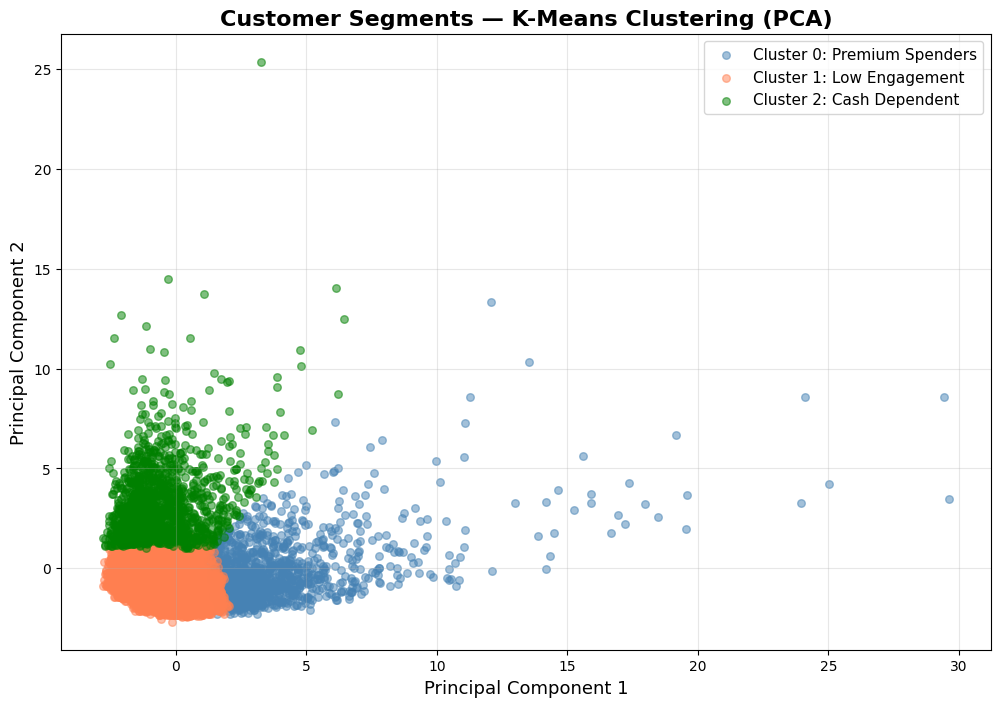

Cluster scatter plot saved!


In [15]:
#Step 13 — PCA Scatter Plot (Cluster Visualization)

from sklearn.decomposition import PCA

# Reduce to 2D using PCA
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(df_scaled)

# Create PCA dataframe
pca_df = pd.DataFrame(pca_coords, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df['Cluster']

# Plot
colors = {0: 'steelblue', 1: 'coral', 2: 'green'}
labels = {0: 'Cluster 0: Premium Spenders', 
          1: 'Cluster 1: Low Engagement', 
          2: 'Cluster 2: Cash Dependent'}

plt.figure(figsize=(12, 8))
for cluster in [0, 1, 2]:
    mask = pca_df['Cluster'] == cluster
    plt.scatter(pca_df[mask]['PC1'], 
                pca_df[mask]['PC2'],
                c=colors[cluster], 
                label=labels[cluster],
                alpha=0.5, s=30)

plt.title('Customer Segments — K-Means Clustering (PCA)', fontsize=16, fontweight='bold')
plt.xlabel('Principal Component 1', fontsize=13)
plt.ylabel('Principal Component 2', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.savefig('cluster_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Cluster scatter plot saved!")

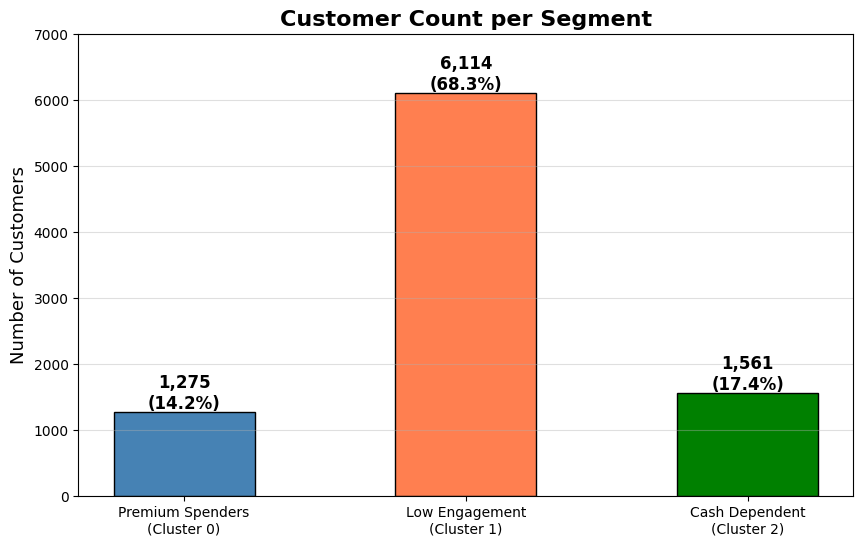

Bar chart saved!


In [16]:
#Step 14 — Cluster Size Bar Chart

# Bar chart - customer count per cluster
cluster_counts = df['Cluster'].value_counts().sort_index()
cluster_names = ['Premium Spenders\n(Cluster 0)', 
                 'Low Engagement\n(Cluster 1)', 
                 'Cash Dependent\n(Cluster 2)']
colors = ['steelblue', 'coral', 'green']

plt.figure(figsize=(10, 6))
bars = plt.bar(cluster_names, cluster_counts, color=colors, edgecolor='black', width=0.5)

# Add count labels on top of bars
for bar, count in zip(bars, cluster_counts):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 50,
             f'{count:,}\n({count/len(df)*100:.1f}%)', 
             ha='center', fontsize=12, fontweight='bold')

plt.title('Customer Count per Segment', fontsize=16, fontweight='bold')
plt.ylabel('Number of Customers', fontsize=13)
plt.ylim(0, 7000)
plt.grid(axis='y', alpha=0.4)
plt.savefig('cluster_barchart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Bar chart saved!")

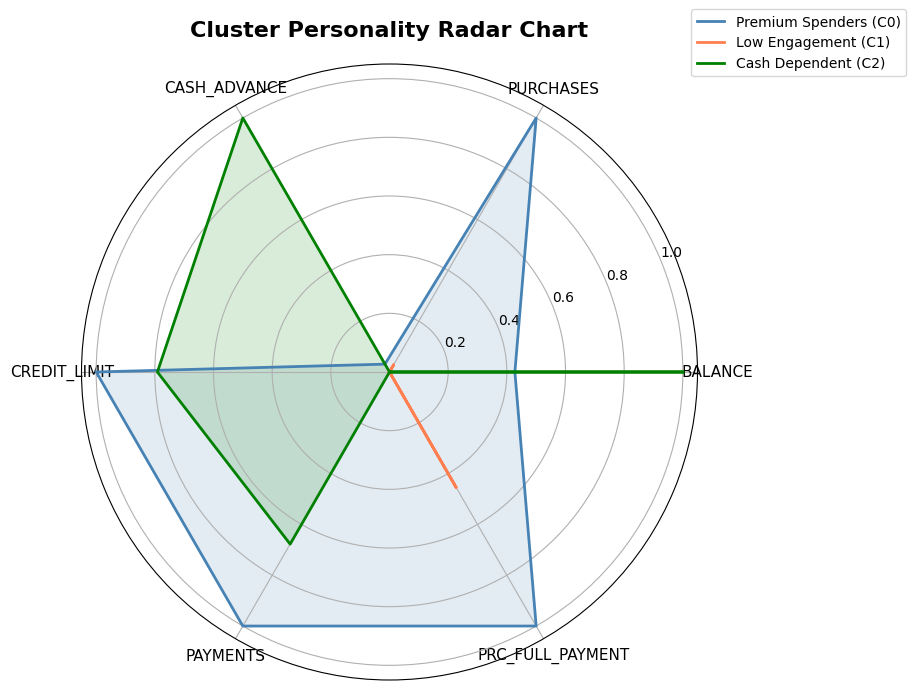

Radar chart saved!


In [17]:
#Step 15 — Radar Chart (Cluster Personality Comparison)

import numpy as np

# Radar chart data
categories = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 
              'CREDIT_LIMIT', 'PAYMENTS', 'PRC_FULL_PAYMENT']

# Normalize cluster profiles (0 to 1) for radar
radar_data = df.groupby('Cluster')[categories].mean()
radar_normalized = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())

# Radar setup
N = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the circle

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(polar=True))

colors = ['steelblue', 'coral', 'green']
cluster_names = ['Premium Spenders (C0)', 'Low Engagement (C1)', 'Cash Dependent (C2)']

for i, (idx, row) in enumerate(radar_normalized.iterrows()):
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, color=colors[i], linewidth=2, label=cluster_names[i])
    ax.fill(angles, values, color=colors[i], alpha=0.15)

# Labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_title('Cluster Personality Radar Chart', 
             fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)

plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Radar chart saved!")

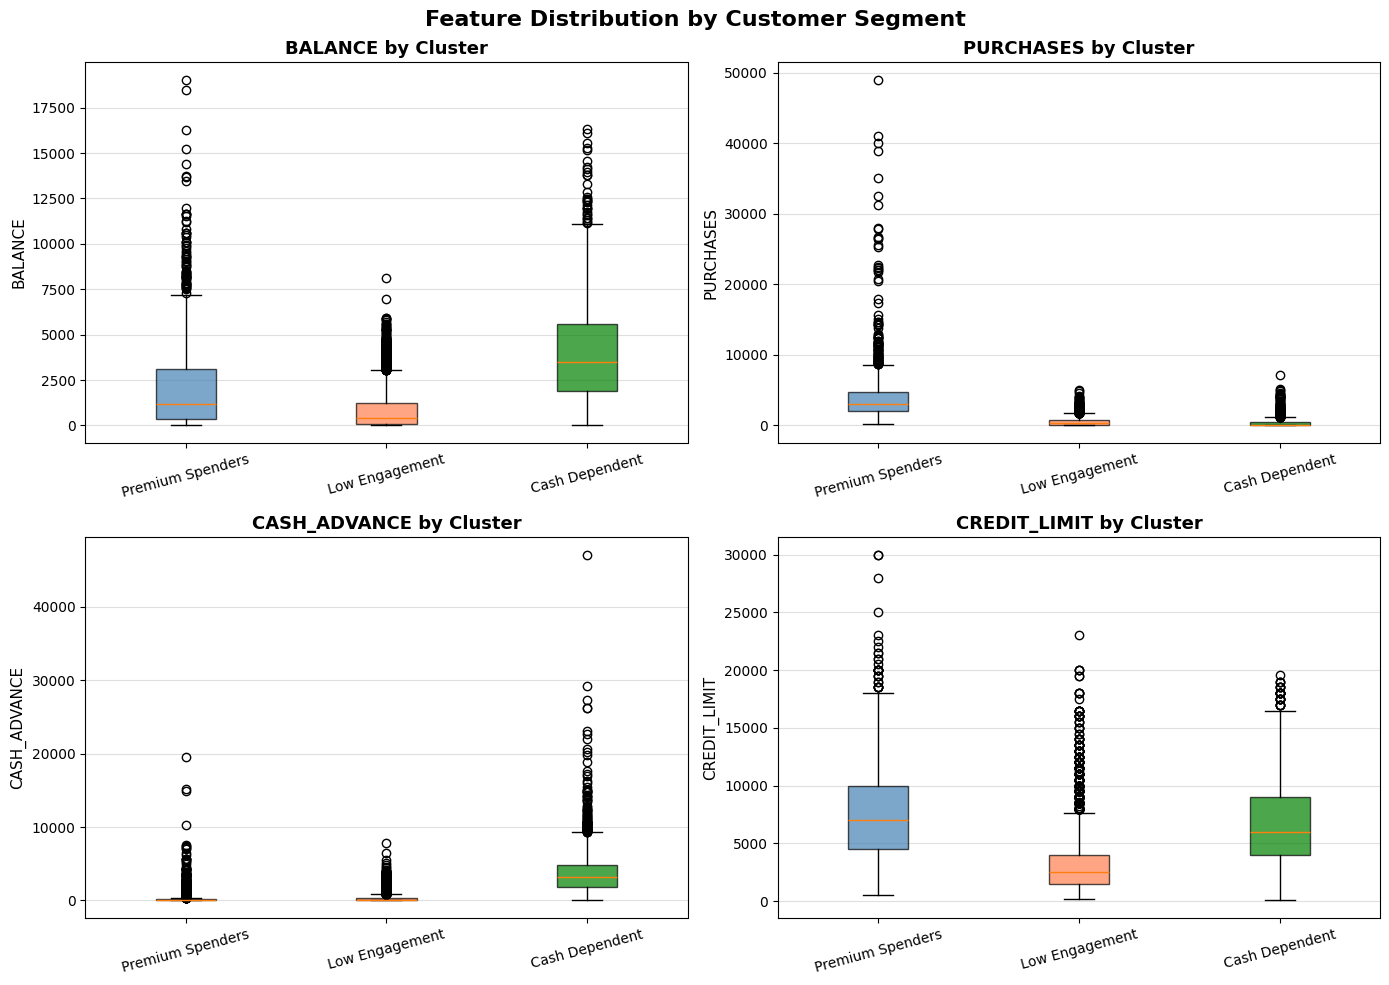

Cluster boxplots saved!


In [19]:
#Step 16 — Box Plots by Cluster (Final Visual)

# Box plots split by cluster - Fixed version
cols = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = ['steelblue', 'coral', 'green']
cluster_names = ['Premium Spenders', 'Low Engagement', 'Cash Dependent']

for i, col in enumerate(cols):
    data_by_cluster = [df[df['Cluster'] == c][col].values for c in [0, 1, 2]]
    bp = axes[i].boxplot(data_by_cluster, patch_artist=True, tick_labels=cluster_names)
    
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    axes[i].set_title(f'{col} by Cluster', fontsize=13, fontweight='bold')
    axes[i].set_ylabel(col, fontsize=11)
    axes[i].grid(axis='y', alpha=0.4)
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Feature Distribution by Customer Segment', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots_by_cluster.png', dpi=150, bbox_inches='tight')
plt.show()
print("Cluster boxplots saved!")

In [20]:
#Step 17 — Statistical Validation (ANOVA Test)

from scipy import stats

print("=== ANOVA Test — Are Clusters Statistically Different? ===\n")

key_cols = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 
            'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS']

for col in key_cols:
    cluster0 = df[df['Cluster'] == 0][col]
    cluster1 = df[df['Cluster'] == 1][col]
    cluster2 = df[df['Cluster'] == 2][col]
    
    f_stat, p_value = stats.f_oneway(cluster0, cluster1, cluster2)
    
    result = "Significant" if p_value < 0.05 else "Not Significant"
    print(f"{col:30} → F={f_stat:.2f}, p={p_value:.6f} {result}")

=== ANOVA Test — Are Clusters Statistically Different? ===

BALANCE                        → F=2370.38, p=0.000000 Significant
PURCHASES                      → F=2618.89, p=0.000000 Significant
CASH_ADVANCE                   → F=3174.93, p=0.000000 Significant
CREDIT_LIMIT                   → F=1492.92, p=0.000000 Significant
PAYMENTS                       → F=1016.47, p=0.000000 Significant
MINIMUM_PAYMENTS               → F=203.12, p=0.000000 Significant


In [21]:
#Step 18 — Export Clustered Dataset

# Export final clustered dataframe
df.to_csv('credit_card_clusters.csv', index=False)
print("Clustered dataset exported as credit_card_clusters.csv")
print(f"Total rows: {len(df)}")
print(f"Columns: {list(df.columns)}")

Clustered dataset exported as credit_card_clusters.csv
Total rows: 8950
Columns: ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE', 'Cluster']


In [22]:
#Step 19 — Business Insights Summary

# Final Business Insights Summary
insights = {
    0: {
        "name": "Premium Active Spenders",
        "size": len(df[df['Cluster'] == 0]),
        "avg_purchases": df[df['Cluster'] == 0]['PURCHASES'].mean().round(2),
        "avg_balance": df[df['Cluster'] == 0]['BALANCE'].mean().round(2),
        "avg_cash_advance": df[df['Cluster'] == 0]['CASH_ADVANCE'].mean().round(2),
        "avg_credit_limit": df[df['Cluster'] == 0]['CREDIT_LIMIT'].mean().round(2),
        "full_payment_rate": df[df['Cluster'] == 0]['PRC_FULL_PAYMENT'].mean().round(2),
        "recommendation": "Offer premium rewards, higher credit limits & loyalty programs"
    },
    1: {
        "name": "Low Engagement Customers",
        "size": len(df[df['Cluster'] == 1]),
        "avg_purchases": df[df['Cluster'] == 1]['PURCHASES'].mean().round(2),
        "avg_balance": df[df['Cluster'] == 1]['BALANCE'].mean().round(2),
        "avg_cash_advance": df[df['Cluster'] == 1]['CASH_ADVANCE'].mean().round(2),
        "avg_credit_limit": df[df['Cluster'] == 1]['CREDIT_LIMIT'].mean().round(2),
        "full_payment_rate": df[df['Cluster'] == 1]['PRC_FULL_PAYMENT'].mean().round(2),
        "recommendation": "Send activation offers, cashback deals & spending incentives"
    },
    2: {
        "name": "Cash Dependent Risk Customers",
        "size": len(df[df['Cluster'] == 2]),
        "avg_purchases": df[df['Cluster'] == 2]['PURCHASES'].mean().round(2),
        "avg_balance": df[df['Cluster'] == 2]['BALANCE'].mean().round(2),
        "avg_cash_advance": df[df['Cluster'] == 2]['CASH_ADVANCE'].mean().round(2),
        "avg_credit_limit": df[df['Cluster'] == 2]['CREDIT_LIMIT'].mean().round(2),
        "full_payment_rate": df[df['Cluster'] == 2]['PRC_FULL_PAYMENT'].mean().round(2),
        "recommendation": "Monitor risk, offer debt restructuring & financial counseling"
    }
}

print("=" * 60)
print("   CREDIT CARD CUSTOMER SEGMENTATION — INSIGHTS REPORT")
print("=" * 60)

for cluster_id, info in insights.items():
    print(f"\nCluster {cluster_id}: {info['name']}")
    print(f"  Customers      : {info['size']:,}")
    print(f"  Avg Purchases  : ${info['avg_purchases']:,.2f}")
    print(f"  Avg Balance    : ${info['avg_balance']:,.2f}")
    print(f"  Avg Cash Adv   : ${info['avg_cash_advance']:,.2f}")
    print(f"  Avg Credit Lim : ${info['avg_credit_limit']:,.2f}")
    print(f"  Full Pay Rate  : {info['full_payment_rate']*100:.0f}%")
    print(f"  Action      : {info['recommendation']}")
    print("-" * 60)

print("\n Insights Summary Complete!")

   CREDIT CARD CUSTOMER SEGMENTATION — INSIGHTS REPORT

Cluster 0: Premium Active Spenders
  Customers      : 1,275
  Avg Purchases  : $4,187.02
  Avg Balance    : $2,182.35
  Avg Cash Adv   : $449.75
  Avg Credit Lim : $7,642.78
  Full Pay Rate  : 30%
  Action      : Offer premium rewards, higher credit limits & loyalty programs
------------------------------------------------------------

Cluster 1: Low Engagement Customers
  Customers      : 6,114
  Avg Purchases  : $496.06
  Avg Balance    : $807.72
  Avg Cash Adv   : $339.00
  Avg Credit Lim : $3,267.02
  Full Pay Rate  : 15%
  Action      : Send activation offers, cashback deals & spending incentives
------------------------------------------------------------

Cluster 2: Cash Dependent Risk Customers
  Customers      : 1,561
  Avg Purchases  : $389.05
  Avg Balance    : $4,023.79
  Avg Cash Adv   : $3,917.25
  Avg Credit Lim : $6,729.47
  Full Pay Rate  : 3%
  Action      : Monitor risk, offer debt restructuring & financial coun

In [23]:
#Streamlit Dashboard!
#Step 1 — Install Streamlit

!pip install streamlit


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
